In [2]:
using LinearAlgebra
using Printf
using Plots


In [3]:
function mat_prod(A, B)
    A_nrow, A_ncol = size(A)
    B_nrow, B_ncol = size(B)

    if A_ncol != B_nrow
        println("A multiplicação não pode ser feita entre as matrizes.")

    else
        C = zeros(A_nrow, B_ncol)
        for i in 1:A_nrow
            for j in 1:B_ncol
                C[i,j] = sum(A[i,k]*B[k,j] for k in 1:A_ncol)
            end
        end
        return C
    end
end

mat_prod (generic function with 1 method)

In [4]:
function mat_dot_prod(A, B)
    A_nrow, A_ncol = size(A)
    B_nrow, B_ncol = size(B)

    if A_ncol != B_nrow
        println("A multiplicação não pode ser feita entre as matrizes.")

    else
        C = zeros(A_nrow, B_ncol)
        for i in 1:A_nrow
            for j in 1:B_ncol
                @views C[i,j] = dot(A[i,:],B[:,j])
            end
        end
        return C
    end
end

mat_dot_prod (generic function with 1 method)

In [5]:
function mat_dot_prod(A, B)
    A_nrow, A_ncol = size(A)
    B_nrow, B_ncol = size(B)
    A_ncol != B_nrow && return println("Dimensões incompatíveis.")
    
    At = transpose(A)  # ← transposta: agora At[:,i] = linha i de A (contíguo!)
    C = zeros(A_nrow, B_ncol)
    for i in 1:A_nrow
        for j in 1:B_ncol
            @views C[i,j] = dot(At[:,i], B[:,j])  # ambos contíguos agora ✅
        end
    end
    return C
end

mat_dot_prod (generic function with 1 method)

In [6]:
A = [1 0 0; 0 1 0; 0 0 1]
B = [1 2 3; 1 2 3; 1 2 3]

display(mat_prod(A,B))
display(mat_dot_prod(A,B))

3×3 Matrix{Float64}:
 1.0  2.0  3.0
 1.0  2.0  3.0
 1.0  2.0  3.0

3×3 Matrix{Float64}:
 1.0  2.0  3.0
 1.0  2.0  3.0
 1.0  2.0  3.0

In [7]:
function calcularTempo_julia(A, B, num_times=100)
    # Warm-up (aquecimento)
    for i in 1:20
        mat_dot_prod(A,B)
    end
    
    arr = zeros(Float64, num_times)
    
    for i in 1:num_times
        initial_time = time_ns()
        mat_dot_prod(A,B)
        final_time = time_ns()
        
        # Convertendo de nanossegundos para segundos
        arr[i] = (final_time - initial_time) / 1e9
    end
    
    min_time = minimum(arr)
    
    # Exibe sempre em segundos, forçando 9 casas decimais
    @printf("Tempo mínimo da multiplicação: %.9f s\n", min_time)
    
    return min_time
end

calcularTempo_julia (generic function with 2 methods)

In [ ]:
# sizes_long = [(100,400), (50,500), (200,1000)]
# sizes_wide = [(400,100), (500,50), (1000,200)]
# sizes = [(5,5), (15,15), (1000, 1000), (2000, 2000)]
# for size in sizes_long
#     i,j = size
#     display(calcularTempo_julia(rand(i,j), rand(j,i)))
#     @time mat_dot_prod(rand(i,j), rand(j,i))
# end

0.0014652

Tempo mínimo da multiplicação: 0.001465200 s
  0.001922 seconds (9 allocations: 703.474 KiB)


Tamanho:   5 | Tempo mínimo: 0.000000300 s
Tamanho:  35 | Tempo mínimo: 0.000025700 s
Tamanho:  65 | Tempo mínimo: 0.000126100 s
Tamanho:  95 | Tempo mínimo: 0.000318100 s
Tamanho: 125 | Tempo mínimo: 0.000751300 s
Tamanho: 155 | Tempo mínimo: 0.001603900 s
Tamanho: 185 | Tempo mínimo: 0.002356100 s
Tamanho: 215 | Tempo mínimo: 0.004092900 s
Tamanho: 245 | Tempo mínimo: 0.006304100 s
Tamanho: 275 | Tempo mínimo: 0.008826200 s
Tamanho: 305 | Tempo mínimo: 0.012346000 s
Tamanho: 335 | Tempo mínimo: 0.015828700 s
Tamanho: 365 | Tempo mínimo: 0.023195100 s
Tamanho: 395 | Tempo mínimo: 0.029197900 s
Tamanho: 425 | Tempo mínimo: 0.035787700 s
Tamanho: 455 | Tempo mínimo: 0.044118200 s
Tamanho: 485 | Tempo mínimo: 0.049696400 s
Tamanho: 515 | Tempo mínimo: 0.058995000 s
Tamanho: 545 | Tempo mínimo: 0.069694900 s
Tamanho: 575 | Tempo mínimo: 0.080023200 s


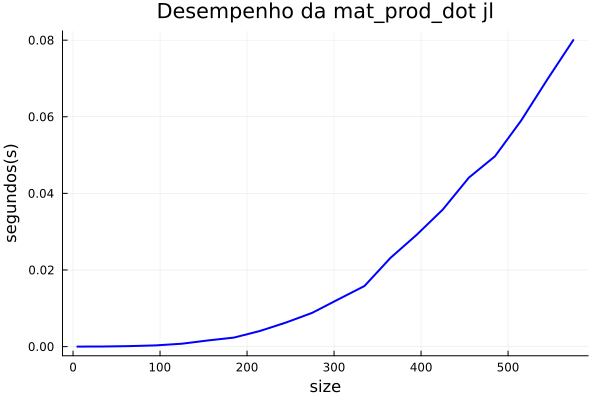

([5, 35, 65, 95, 125, 155, 185, 215, 245, 275, 305, 335, 365, 395, 425, 455, 485, 515, 545, 575], [3.0e-7, 2.57e-5, 0.0001261, 0.0003181, 0.0007513, 0.0016039, 0.0023561, 0.0040929, 0.0063041, 0.0088262, 0.012346, 0.0158287, 0.0231951, 0.0291979, 0.0357877, 0.0441182, 0.0496964, 0.058995, 0.0696949, 0.0800232])

In [12]:
function calcularTempo_suafuncao(A, B, num_times=10)
    for i in 1:3
        mat_dot_prod(A, B)
    end
    arr = zeros(Float64, num_times)
    for i in 1:num_times
        initial_time = time_ns()
        mat_dot_prod(A, B)
        final_time = time_ns()
        arr[i] = (final_time - initial_time) / 1e9
    end
    return minimum(arr)
end

function avaliar_e_plotar_mat_dot_prod()
    tamanhos = Int[]
    tempos = Float64[]
    
    for size in 5:30:600
        PAD = 7
        A_pad = rand(size, size + PAD)
        B_pad = rand(size, size + PAD)
        
        # ✅ @view preserva o stride — sem isso é só uma cópia normal
        A = @view A_pad[:, 1:size]
        B = @view B_pad[:, 1:size]
        
        GC.gc()
        tempo_estavel = calcularTempo_suafuncao(A, B)
        @printf("Tamanho: %3d | Tempo mínimo: %.9f s\n", size, tempo_estavel)
        push!(tamanhos, size)
        push!(tempos, tempo_estavel)
    end
    
    grafico = plot(tamanhos, tempos,
        marker = false, linewidth = 2,
        title = "Desempenho da mat_prod_dot jl",
        xlabel = "size", ylabel = "segundos(s)",
        legend = false, color = :blue)
    
    savefig(grafico, "desempenho_mat_dot_prod.png")
    display(grafico)
    return tamanhos, tempos
end

x_dot, y_dot = avaliar_e_plotar_mat_dot_prod()